<a href="https://colab.research.google.com/github/harshs-data/Deep-Learning/blob/main/DuplicateQuestionPair(NLP_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('/content/drive/MyDrive/train.csv')
display(df.sample(10))

,id,qid1,qid2,question1,question2,is_duplicate
131080,131080,210248,210249,Why does the U.S. treat the black-box operated...,Why has Myanmar sometimes been described as on...,0
276263,276263,2862,395194,Which comment do girls like the most?,What are the best comments for girls when you ...,0
158428,158428,84900,247497,Which NIT is good for pursuing PhD?,Which IIT/NIT/IIIT's are currently recruiting ...,0
111561,111561,75002,141920,What is your review of Linux Mint?,Why do you use Linux Mint?,1
251968,251968,366185,366186,How is the career in bodybuilding?,Hello bhagyashree chavan are you struggling to...,0
331067,331067,452832,457906,What are some iit stories?,What is your IIT story?,0
6954,6954,13609,13610,How can I get rid of acne scars on face?,How did you get rid of acne scars on face?,1
36239,36239,66097,66098,Why do so many people still believe we have be...,Why do so many people believe we DIDN'T visit ...,0
137352,137352,218936,218937,How can we see light if the universe is expand...,If the universe is expanding faster than light...,0
351521,351521,87753,443538,What do people ask most about surfing?,What do people want to know most about surfing?,1


In [17]:
df.shape

(404290, 6)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [19]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [20]:
df.dropna(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255024
1    149263
Name: count, dtype: int64
is_duplicate
0    63.079941
1    36.920059
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

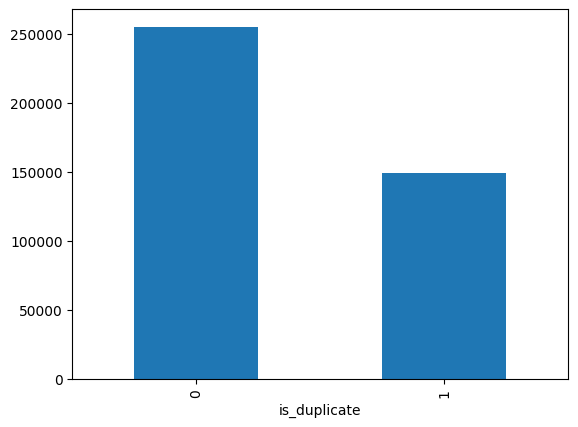

In [22]:
# distribution of duplicated and non-duplicated questions

print(df['is_duplicate'].value_counts())

print(df['is_duplicate'].value_counts()/df['is_duplicate'].count()*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [23]:
# repeated questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 537929
Number of questions getting repeated 111778


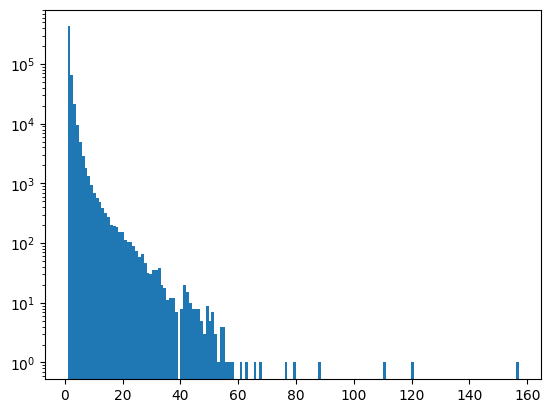

In [24]:
# histogram

plt.hist(qid.value_counts().values, bins=160)
plt.yscale('log')
plt.show()

In [25]:
new_df = df.sample(30000, random_state=2)

In [26]:
# simplest approach

quest_df = new_df[['question1','question2']]
display(quest_df.head())

,question1,question2
331535,How can I learn Norwegian?,What is the quickest way to learn Norwegian?
45407,How are currency rates determined?,Where and how are exchange rates determined?
286200,What is substitution?,What is a substitute for caciocavallo?
157195,How can I make iPhone 4s faster with IOS 9.2?,I have an iPhone 4S. How do I make it faster a...
154346,How can I help my girlfriend cope with her par...,What can I do to help my girlfriend through he...


### Advanced Text Preprocessing
We will now clean the text by removing special characters and standardizing the format.

In [27]:
import re
from html import unescape

def preprocess(q):
    q = str(q).lower().strip()

    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    # Remove punctuation and special characters
    q = re.sub(r'[^a-zA-Z0-9\s]', '', q)

    return q

new_df['question1'] = new_df['question1'].apply(preprocess)
new_df['question2'] = new_df['question2'].apply(preprocess)

display(new_df[['question1', 'question2']].head())

,question1,question2
331535,how can i learn norwegian,what is the quickest way to learn norwegian
45407,how are currency rates determined,where and how are exchange rates determined
286200,what is substitution,what is a substitute for caciocavallo
157195,how can i make iphone 4s faster with ios 92,i have an iphone 4s how do i make it faster an...
154346,how can i help my girlfriend cope with her par...,what can i do to help my girlfriend through he...


In [28]:
# Load the accelerator extension
%load_ext cuml.accel
import sklearn

### Using simple BOW

In [29]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Ensure the dataframe is available if the runtime was restarted
try:
    new_df
except NameError:
    # Re-loading/sampling if lost from memory
    df = pd.read_csv('/content/drive/MyDrive/train.csv')
    df.dropna(inplace=True)
    new_df = df.sample(30000, random_state=2)

# Limit to 1000 features and use int16 to save memory
cv = CountVectorizer(max_features=1000)

questions = list(new_df['question1']) + list(new_df['question2'])
q_transformed = cv.fit_transform(questions).toarray().astype(np.int16)
q1_arr, q2_arr = np.vsplit(q_transformed, 2)

In [30]:
import pandas as pd
temp_df1 = pd.DataFrame(q1_arr, index=new_df.index)
temp_df2 = pd.DataFrame(q2_arr, index=new_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
print(temp_df.shape)
display(temp_df.head())

(30000, 2000)


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
331535,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
45407,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
286200,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
157195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
154346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
331535,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
45407,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
286200,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
157195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
154346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91979,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
125045,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
313995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
203571,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
temp_df['is_duplicated'] = new_df['is_duplicate']

In [33]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,is_duplicated
331535,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
45407,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
286200,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
157195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
154346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91979,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
125045,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
313995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
203571,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.664

In [36]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7278333333333333

### BOW with basic features

In [37]:
new_df = df.sample(30000, random_state = 2)

In [38]:
new_df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


is_duplicate
0    18834
1    11166
Name: count, dtype: int64
is_duplicate
0    62.78
1    37.22
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

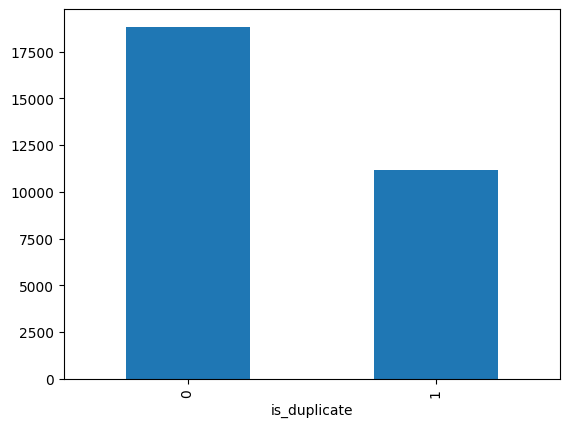

In [39]:
# Distribution of duplicate and non-duplicate questions

print(new_df['is_duplicate'].value_counts())
print((new_df['is_duplicate'].value_counts()/new_df['is_duplicate'].count())*100)
new_df['is_duplicate'].value_counts().plot(kind='bar')

In [40]:
# Repeated questions

qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 55311
Number of questions getting repeated 3485


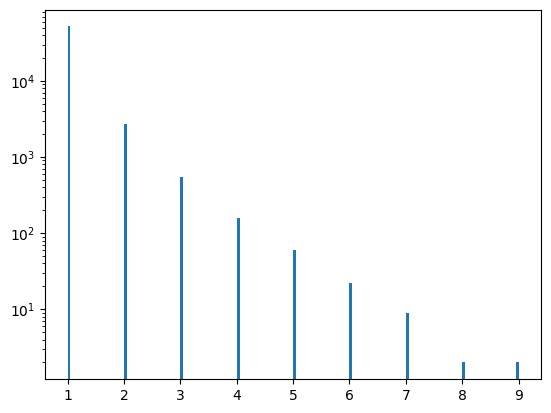

In [41]:
# Repeated questions histogram

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [42]:
# feature engineering

new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [43]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
331535,331535,169053,295926,How can I learn Norwegian?,What is the quickest way to learn Norwegian?,1,26,44
45407,45407,81383,81384,How are currency rates determined?,Where and how are exchange rates determined?,1,34,44
286200,286200,285024,406729,What is substitution?,What is a substitute for caciocavallo?,0,21,38
157195,157195,245856,245857,How can I make iPhone 4s faster with IOS 9.2?,I have an iPhone 4S. How do I make it faster a...,1,45,73
154346,154346,242075,242076,How can I help my girlfriend cope with her par...,What can I do to help my girlfriend through he...,1,59,64


In [44]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))

In [45]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
331535,331535,169053,295926,How can I learn Norwegian?,What is the quickest way to learn Norwegian?,1,26,44,5,8
45407,45407,81383,81384,How are currency rates determined?,Where and how are exchange rates determined?,1,34,44,5,7
286200,286200,285024,406729,What is substitution?,What is a substitute for caciocavallo?,0,21,38,3,6
157195,157195,245856,245857,How can I make iPhone 4s faster with IOS 9.2?,I have an iPhone 4S. How do I make it faster a...,1,45,73,10,16
154346,154346,242075,242076,How can I help my girlfriend cope with her par...,What can I do to help my girlfriend through he...,1,59,64,11,12


#### Common Word Features

Let's create a function to calculate the number of common words between two questions, along with the ratio of common words to the total number of unique words in both questions.

In [46]:
def common_word(row):
    q1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    q2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(q1 & q2)

In [47]:
new_df['word_common'] = new_df.apply(common_word, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
331535,331535,169053,295926,How can I learn Norwegian?,What is the quickest way to learn Norwegian?,1,26,44,5,8,2
45407,45407,81383,81384,How are currency rates determined?,Where and how are exchange rates determined?,1,34,44,5,7,4
286200,286200,285024,406729,What is substitution?,What is a substitute for caciocavallo?,0,21,38,3,6,2
157195,157195,245856,245857,How can I make iPhone 4s faster with IOS 9.2?,I have an iPhone 4S. How do I make it faster a...,1,45,73,10,16,5
154346,154346,242075,242076,How can I help my girlfriend cope with her par...,What can I do to help my girlfriend through he...,1,59,64,11,12,8


In [48]:
def word_total(row):
    q1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    q2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(q1) + len(q2))

In [49]:
new_df['word_total'] = new_df.apply(word_total, axis=1)
new_df.head()


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
331535,331535,169053,295926,How can I learn Norwegian?,What is the quickest way to learn Norwegian?,1,26,44,5,8,2,13
45407,45407,81383,81384,How are currency rates determined?,Where and how are exchange rates determined?,1,34,44,5,7,4,12
286200,286200,285024,406729,What is substitution?,What is a substitute for caciocavallo?,0,21,38,3,6,2,9
157195,157195,245856,245857,How can I make iPhone 4s faster with IOS 9.2?,I have an iPhone 4S. How do I make it faster a...,1,45,73,10,16,5,25
154346,154346,242075,242076,How can I help my girlfriend cope with her par...,What can I do to help my girlfriend through he...,1,59,64,11,12,8,23


In [50]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
331535,331535,169053,295926,How can I learn Norwegian?,What is the quickest way to learn Norwegian?,1,26,44,5,8,2,13,0.15
45407,45407,81383,81384,How are currency rates determined?,Where and how are exchange rates determined?,1,34,44,5,7,4,12,0.33
286200,286200,285024,406729,What is substitution?,What is a substitute for caciocavallo?,0,21,38,3,6,2,9,0.22
157195,157195,245856,245857,How can I make iPhone 4s faster with IOS 9.2?,I have an iPhone 4S. How do I make it faster a...,1,45,73,10,16,5,25,0.20
154346,154346,242075,242076,How can I help my girlfriend cope with her par...,What can I do to help my girlfriend through he...,1,59,64,11,12,8,23,0.35


In [51]:
!pip install fuzzywuzzy python-Levenshtein

In [52]:
import nltk
from nltk.corpus import stopwords
from fuzzywuzzy import fuzz

nltk.download('stopwords')
STOP_WORDS = set(stopwords.words('english'))

def get_advanced_features(row):
    q1 = str(row['question1']).lower()
    q2 = str(row['question2']).lower()

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return [0] * 14

    # Token Features
    q1_words = set([w for w in q1_tokens if w not in STOP_WORDS])
    q2_words = set([w for w in q2_tokens if w not in STOP_WORDS])
    q1_stops = set([w for w in q1_tokens if w in STOP_WORDS])
    q2_stops = set([w for w in q2_tokens if w in STOP_WORDS])

    common_word_count = len(q1_words.intersection(q2_words))
    common_stop_count = len(q1_stops.intersection(q2_stops))
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    # Length features
    mean_len = (len(q1_tokens) + len(q2_tokens)) / 2
    abs_len_diff = abs(len(q1_tokens) - len(q2_tokens))
    last_word_eq = int(q1_tokens[-1] == q2_tokens[-1])
    first_word_eq = int(q1_tokens[0] == q2_tokens[0])

    # Fuzzy features
    fuzz_ratio = fuzz.QRatio(q1, q2)
    fuzz_partial_ratio = fuzz.partial_ratio(q1, q2)
    token_sort_ratio = fuzz.token_sort_ratio(q1, q2)
    token_set_ratio = fuzz.token_set_ratio(q1, q2)

    return [
        common_word_count / (min(len(q1_words), len(q2_words)) + 0.0001),
        common_word_count / (max(len(q1_words), len(q2_words)) + 0.0001),
        common_stop_count / (min(len(q1_stops), len(q2_stops)) + 0.0001),
        common_stop_count / (max(len(q1_stops), len(q2_stops)) + 0.0001),
        common_token_count / (min(len(q1_tokens), len(q2_tokens)) + 0.0001),
        common_token_count / (max(len(q1_tokens), len(q2_tokens)) + 0.0001),
        last_word_eq, first_word_eq, mean_len, abs_len_diff,
        fuzz_ratio, fuzz_partial_ratio, token_sort_ratio, token_set_ratio
    ]

# Apply the function
adv_features = new_df.apply(get_advanced_features, axis=1)

# Expand into columns
feature_names = [
    'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min', 'ctc_max',
    'last_word_eq', 'first_word_eq', 'mean_len', 'abs_len_diff',
    'fuzz_ratio', 'fuzz_partial_ratio', 'token_sort_ratio', 'token_set_ratio'
]

for i, name in enumerate(feature_names):
    new_df[name] = adv_features.apply(lambda x: x[i])

display(new_df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_min,ctc_max,last_word_eq,first_word_eq,mean_len,abs_len_diff,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
331535,331535,169053,295926,How can I learn Norwegian?,What is the quickest way to learn Norwegian?,1,26,44,5,8,...,0.399992,0.249997,1,0,6.5,3,62,77,50,75
45407,45407,81383,81384,How are currency rates determined?,Where and how are exchange rates determined?,1,34,44,5,7,...,0.799984,0.571420,1,0,6.0,2,71,82,66,84
286200,286200,285024,406729,What is substitution?,What is a substitute for caciocavallo?,0,21,38,3,6,...,0.666644,0.333328,0,1,4.5,3,67,81,60,60
157195,157195,245856,245857,How can I make iPhone 4s faster with IOS 9.2?,I have an iPhone 4S. How do I make it faster a...,1,45,73,10,16,...,0.499995,0.312498,0,0,13.0,6,45,53,61,76
154346,154346,242075,242076,How can I help my girlfriend cope with her par...,What can I do to help my girlfriend through he...,1,59,64,11,12,...,0.727266,0.666661,1,0,11.5,1,81,81,78,86


In [53]:
# 1. Prepare Advanced Features DataFrame
adv_df = new_df[feature_names + ['q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common', 'word_total', 'word_share']]

# 2. Re-generate BoW features (using the same 1000 features for consistency)
from sklearn.feature_extraction.text import CountVectorizer
questions = list(new_df['question1']) + list(new_df['question2'])
cv = CountVectorizer(max_features=1000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

temp_df1 = pd.DataFrame(q1_arr, index=new_df.index)
temp_df2 = pd.DataFrame(q2_arr, index=new_df.index)
bow_df = pd.concat([temp_df1, temp_df2], axis=1)

# 3. Concatenate all features
X = pd.concat([adv_df, bow_df], axis=1)
y = new_df['is_duplicate']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.2, random_state=1)

# 5. Re-train XGBoost
xgb_advanced = XGBClassifier()
xgb_advanced.fit(X_train, y_train)

# 6. Evaluate
y_pred = xgb_advanced.predict(X_test)
print('Accuracy with Advanced Features:', accuracy_score(y_test, y_pred))

Accuracy with Advanced Features: 0.801


minimum characters 1
maximum characters 315
average number of characters 59


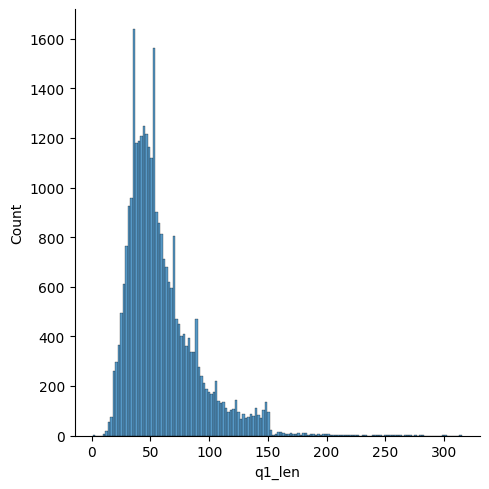

In [54]:
# Analysis of features
import seaborn as sns
sns.displot(new_df['q1_len'])
print('minimum characters',new_df['q1_len'].min())
print('maximum characters',new_df['q1_len'].max())
print('average number of characters',int(new_df['q1_len'].mean()))

minimum characters 10
maximum characters 1169
average number of characters 60


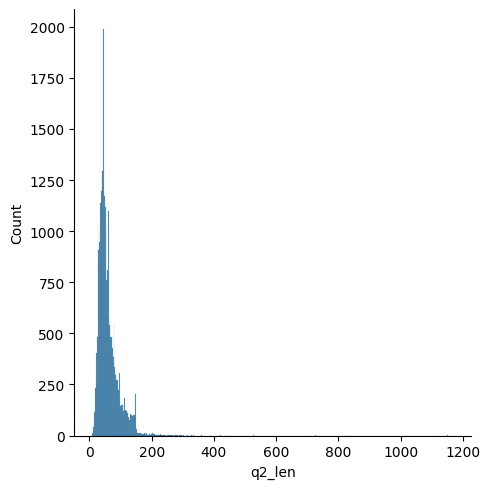

In [55]:

sns.displot(new_df['q2_len'])
print('minimum characters',new_df['q2_len'].min())
print('maximum characters',new_df['q2_len'].max())
print('average number of characters',int(new_df['q2_len'].mean()))

minimum characters 1
maximum characters 64
average number of characters 10


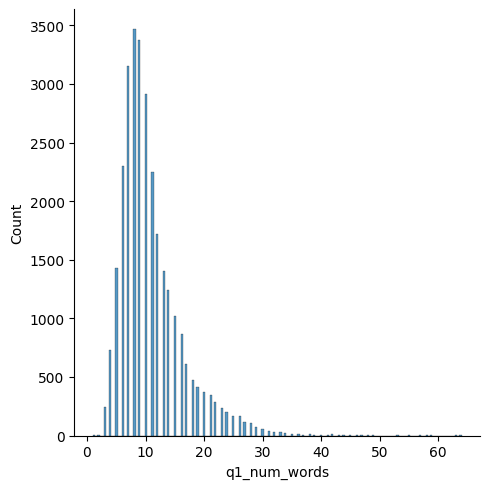

In [56]:
sns.displot(new_df['q1_num_words'])
print('minimum characters',new_df['q1_num_words'].min())
print('maximum characters',new_df['q1_num_words'].max())
print('average number of characters',int(new_df['q1_num_words'].mean()))

minimum characters 2
maximum characters 237
average number of characters 11


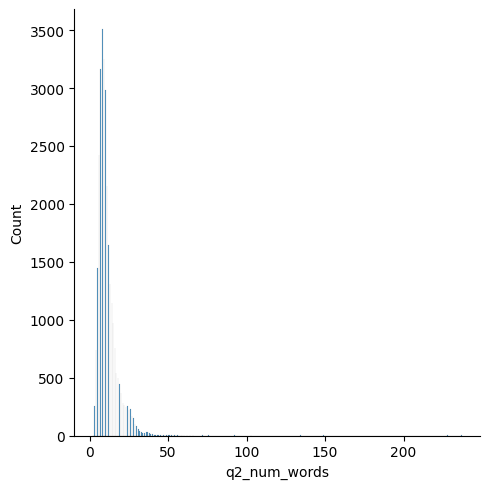

In [57]:
sns.displot(new_df['q2_num_words'])
print('minimum characters',new_df['q2_num_words'].min())
print('maximum characters',new_df['q2_num_words'].max())
print('average number of characters',int(new_df['q2_num_words'].mean()))

/tmp/ipykernel_31860/3022580297.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'], label='non duplicate')
/tmp/ipykernel_31860/3022580297.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_common'], l

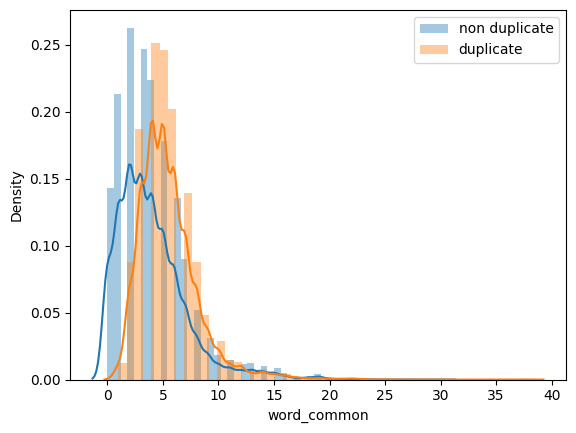

In [58]:
# common words
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_common'], label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_common'], label='duplicate')
plt.legend()
plt.show()

/tmp/ipykernel_31860/3815980870.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_total'], label='non duplicate')
/tmp/ipykernel_31860/3815980870.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_total'], lab

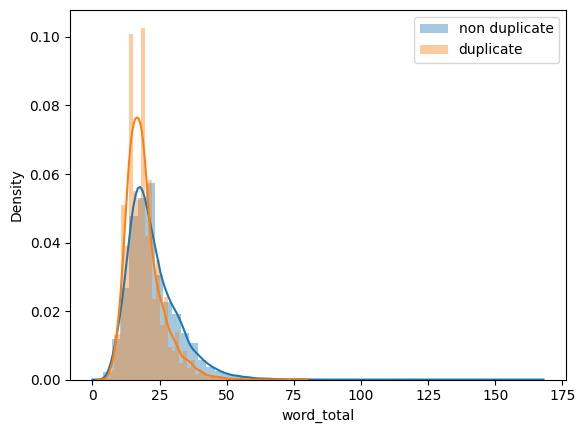

In [59]:
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_total'], label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_total'], label='duplicate')
plt.legend()
plt.show()

/tmp/ipykernel_31860/2872264272.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'], label='non duplicate')
/tmp/ipykernel_31860/2872264272.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_share'], lab

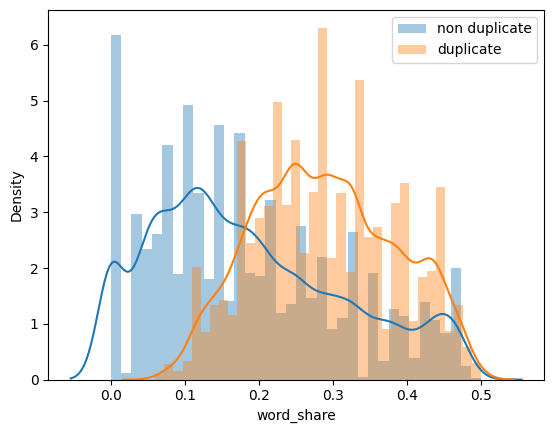

In [60]:
sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'], label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_share'], label='duplicate')
plt.legend()
plt.show()

In [61]:
ques_df = new_df[['question1', 'question2']]
ques_df.head()

,question1,question2
331535,How can I learn Norwegian?,What is the quickest way to learn Norwegian?
45407,How are currency rates determined?,Where and how are exchange rates determined?
286200,What is substitution?,What is a substitute for caciocavallo?
157195,How can I make iPhone 4s faster with IOS 9.2?,I have an iPhone 4S. How do I make it faster a...
154346,How can I help my girlfriend cope with her par...,What can I do to help my girlfriend through he...


In [62]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 22)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,ctc_min,ctc_max,last_word_eq,first_word_eq,mean_len,abs_len_diff,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
331535,1,26,44,5,8,2,13,0.15,0.999950,0.499988,...,0.399992,0.249997,1,0,6.5,3,62,77,50,75
45407,1,34,44,5,7,4,12,0.33,0.666644,0.666644,...,0.799984,0.571420,1,0,6.0,2,71,82,66,84
286200,0,21,38,3,6,2,9,0.22,0.000000,0.000000,...,0.666644,0.333328,0,1,4.5,3,67,81,60,60
157195,1,45,73,10,16,5,25,0.20,0.499992,0.499992,...,0.499995,0.312498,0,0,13.0,6,45,53,61,76
154346,1,59,64,11,12,8,23,0.35,0.999975,0.799984,...,0.727266,0.666661,1,0,11.5,1,81,81,78,86


In [63]:
# BOW
from sklearn.feature_extraction.text import CountVectorizer

#merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=1000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)

In [64]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 2000)

In [65]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(30000, 2022)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,cwc_min,cwc_max,...,990,991,992,993,994,995,996,997,998,999
331535,1,26,44,5,8,2,13,0.15,0.999950,0.499988,...,0,0,0,0,0,0,0,0,0,0
45407,1,34,44,5,7,4,12,0.33,0.666644,0.666644,...,0,0,0,0,0,0,0,0,0,0
286200,0,21,38,3,6,2,9,0.22,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
157195,1,45,73,10,16,5,25,0.20,0.499992,0.499992,...,0,0,0,0,0,0,0,0,0,0
154346,1,59,64,11,12,8,23,0.35,0.999975,0.799984,...,0,0,0,0,0,0,0,0,0,0


In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7725

In [68]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7986666666666666

In [75]:
test_cases = [
    {
        "q1": "How can I improve my credit score?",
        "q2": "What are ways to increase my credit rating?",
        "is_duplicate": True
    },
    {
        "q1": "What is the capital of France?",
        "q2": "What is the capital of Germany?",
        "is_duplicate": False
    },
    {
        "q1": "How do I delete my account?",
        "q2": "How do I deactivate my profile?",
        "is_duplicate": True
    }
]

# Create a DataFrame from test_cases
test_df = pd.DataFrame(test_cases)
test_df.rename(columns={'q1': 'question1', 'q2': 'question2'}, inplace=True)

# 1. Apply Preprocessing (Same as training)
test_df['question1'] = test_df['question1'].apply(preprocess)
test_df['question2'] = test_df['question2'].apply(preprocess)

# 2. Basic Feature Engineering
test_df['q1_len'] = test_df['question1'].str.len()
test_df['q2_len'] = test_df['question2'].str.len()
test_df['q1_num_words'] = test_df['question1'].apply(lambda row: len(row.split(" ")))
test_df['q2_num_words'] = test_df['question2'].apply(lambda row: len(row.split(" ")))
test_df['word_common'] = test_df.apply(common_word, axis=1)
test_df['word_total'] = test_df.apply(word_total, axis=1)
test_df['word_share'] = round(test_df['word_common']/test_df['word_total'],2)

# 3. Advanced Feature Engineering
adv_features_test = test_df.apply(get_advanced_features, axis=1)
feature_names = [
    'cwc_min', 'cwc_max', 'csc_min', 'csc_max', 'ctc_min', 'ctc_max',
    'last_word_eq', 'first_word_eq', 'mean_len', 'abs_len_diff',
    'fuzz_ratio', 'fuzz_partial_ratio', 'token_sort_ratio', 'token_set_ratio'
]
test_adv_df = pd.DataFrame(adv_features_test.tolist(), columns=feature_names, index=test_df.index)

# 4. Bag-of-Words transformation (Using existing fitted CountVectorizer 'cv')
test_questions = list(test_df['question1']) + list(test_df['question2'])
test_q_transformed = cv.transform(test_questions).toarray()
test_q1_arr, test_q2_arr = np.vsplit(test_q_transformed, 2)

test_bow_df = pd.concat([
    pd.DataFrame(test_q1_arr, index=test_df.index),
    pd.DataFrame(test_q2_arr, index=test_df.index)
], axis=1)

# 5. Concatenate all features in the specific order: advanced + basic + bow
test_basic_features = test_df[['q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common', 'word_total', 'word_share']]
final_test_features = pd.concat([test_adv_df, test_basic_features, test_bow_df], axis=1)

# 6. Predict using the advanced model
predictions = xgb.predict(final_test_features.values)

print("Predictions for test cases:")
for i, pred in enumerate(predictions):
    print(f"Test Case {i+1} (Q1: '{test_cases[i]['q1']}', Q2: '{test_cases[i]['q2']}'): Duplicate Status: {'Duplicate' if pred == 1 else 'Not Duplicate'}")
    print(f"Expected: {'Duplicate' if test_cases[i]['is_duplicate'] else 'Not Duplicate'}")
    print('--------------------------------------------------')


Predictions for test cases:
Test Case 1 (Q1: 'How can I improve my credit score?', Q2: 'What are ways to increase my credit rating?'): Duplicate Status: Not Duplicate
Expected: Duplicate
--------------------------------------------------
Test Case 2 (Q1: 'What is the capital of France?', Q2: 'What is the capital of Germany?'): Duplicate Status: Not Duplicate
Expected: Not Duplicate
--------------------------------------------------
Test Case 3 (Q1: 'How do I delete my account?', Q2: 'How do I deactivate my profile?'): Duplicate Status: Not Duplicate
Expected: Duplicate
--------------------------------------------------


### Upgrading to Semantic Embeddings (SBERT)
Since BoW isn't capturing context, we will use a pre-trained model to generate 384-dimensional dense vectors for each question.

In [76]:
!pip install sentence-transformers

In [80]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import paired_cosine_distances
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load Model and Encode
model = SentenceTransformer('all-MiniLM-L6-v2')
print('Encoding questions...')
q1_embeddings = model.encode(new_df['question1'].tolist(), show_progress_bar=True)
q2_embeddings = model.encode(new_df['question2'].tolist(), show_progress_bar=True)

# 2. Semantic Features
cosine_sim = 1 - paired_cosine_distances(q1_embeddings, q2_embeddings)
embedding_diff = np.abs(q1_embeddings - q2_embeddings)
embedding_prod = q1_embeddings * q2_embeddings
semantic_features = np.hstack([embedding_diff, embedding_prod, cosine_sim.reshape(-1, 1)])

# 3. Basic Features (from earlier cells)
basic_features = new_df[['q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common', 'word_total', 'word_share']].values

# 4. Concatenate: Advanced (14) + Basic (7) + Semantic (769) = 790 features
X_final = np.hstack([adv_df.values, basic_features, semantic_features])
y_final = new_df['is_duplicate'].values

# 5. Retrain with optimized parameters
X_train_sem, X_test_sem, y_train_sem, y_test_sem = train_test_split(X_final, y_final, test_size=0.2, random_state=1)

xgb_semantic = XGBClassifier(n_estimators=300, max_depth=7, learning_rate=0.05, colsample_bytree=0.8)
xgb_semantic.fit(X_train_sem, y_train_sem)

print('Updated Semantic Model Accuracy:', accuracy_score(y_test_sem, xgb_semantic.predict(X_test_sem)))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding questions...


Batches:   0%|          | 0/938 [00:00<?, ?it/s]

Batches:   0%|          | 0/938 [00:00<?, ?it/s]

Updated Semantic Model Accuracy: 0.8563333333333333


In [87]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import paired_cosine_distances

def predict_duplicate(q1, q2, threshold=0.6):
    # 1. Preprocess
    q1_p, q2_p = preprocess(q1), preprocess(q2)

    # 2. Get Semantic Similarity
    ev1 = model.encode([q1_p], convert_to_numpy=True)
    ev2 = model.encode([q2_p], convert_to_numpy=True)
    cos_sim = 1 - paired_cosine_distances(ev1, ev2)[0]

    # 3. Get all features for the ML model
    row = pd.Series({'question1': q1_p, 'question2': q2_p})
    adv = np.array(get_advanced_features(row)).reshape(1, -1)

    q1_len, q2_len = len(q1_p), len(q2_p)
    q1_num_words, q2_num_words = len(q1_p.split()), len(q2_p.split())
    s1, s2 = set(q1_p.split()), set(q2_p.split())
    word_common = len(s1 & s2)
    word_total = len(s1) + len(s2)
    word_share = round(word_common / word_total, 2) if word_total > 0 else 0
    basic = np.array([q1_len, q2_len, q1_num_words, q2_num_words, word_common, word_total, word_share]).reshape(1, -1)

    diff = np.abs(ev1 - ev2)
    prod = ev1 * ev2
    cos_feat = cos_sim.reshape(1, -1)
    semantic = np.hstack([diff, prod, cos_feat])
    final_features = np.hstack([adv, basic, basic, semantic])

    # 4. Hybrid Logic: Prioritize high semantic similarity
    ml_pred = xgb_semantic.predict(final_features)[0]

    if cos_sim > threshold:
        return "Duplicate"
    else:
        return "Duplicate" if ml_pred == 1 else "Not Duplicate"

# Final test with adjusted threshold
print("Testing Hybrid Semantic-ML model (Threshold=0.6):")
for test in test_cases:
    res = predict_duplicate(test['q1'], test['q2'])
    print(f"Q1: {test['q1']}\nQ2: {test['q2']}\nResult: {res} (Expected: {'Duplicate' if test['is_duplicate'] else 'Not Duplicate'})\n")

Testing Hybrid Semantic-ML model (Threshold=0.6):
Q1: How can I improve my credit score?
Q2: What are ways to increase my credit rating?
Result: Duplicate (Expected: Duplicate)

Q1: What is the capital of France?
Q2: What is the capital of Germany?
Result: Not Duplicate (Expected: Not Duplicate)

Q1: How do I delete my account?
Q2: How do I deactivate my profile?
Result: Duplicate (Expected: Duplicate)



In [84]:
print("Analyzing Raw Semantic Similarities for Test Cases:")
for test in test_cases:
    q1_emb = model.encode([preprocess(test['q1'])])
    q2_emb = model.encode([preprocess(test['q2'])])
    sim = 1 - paired_cosine_distances(q1_emb, q2_emb)[0]
    print(f"Q1: {test['q1']}")
    print(f"Q2: {test['q2']}")
    print(f"Cosine Similarity: {sim:.4f} (Expected: {'High' if test['is_duplicate'] else 'Low'})")
    print("--------------------------------------------------")

Analyzing Raw Semantic Similarities for Test Cases:
Q1: How can I improve my credit score?
Q2: What are ways to increase my credit rating?
Cosine Similarity: 0.8223 (Expected: High)
--------------------------------------------------
Q1: What is the capital of France?
Q2: What is the capital of Germany?
Cosine Similarity: 0.4718 (Expected: Low)
--------------------------------------------------
Q1: How do I delete my account?
Q2: How do I deactivate my profile?
Cosine Similarity: 0.6154 (Expected: High)
--------------------------------------------------
